# Machine Learning Model that Predictes The Gold ETF Open Price 

In [1]:
# Basic Import liberies for Data Analysis and Cleaning and Processing the Data
import numpy as np
import pandas as pd 
import seaborn as sns
import random as rd
import matplotlib.pyplot as plt

In [2]:
# Read The Data this Data is downloded from Kaggle :
data = pd.read_csv('financial_regression.csv')

In [3]:
data.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

<h3>The data.info() provides us the information that there were 3904 rows and 47 columns. Also Provides us the information that there are lot off NaN valued position in many columns. So we have to do many Data Cleaning Operation on this Data according to our Requirnment</h3>

In [5]:
data.describe()

,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,nasdaq close,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
count,3719.000000,3719.000000,3719.000000,3719.000000,3.719000e+03,3719.000000,3719.000000,3719.000000,3719.00000,3719.000000,...,3719.000000,3719.000000,3719.000000,3.719000e+03,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3.719000e+03
mean,268.732724,270.179765,267.157446,268.779352,1.124206e+08,3.022320,181.394495,182.689784,179.98249,181.431795,...,110.184473,107.931862,109.067990,7.169556e+04,2.252611,145.454975,146.101477,144.761329,145.453861,9.658138e+06
std,121.374890,122.024860,120.663204,121.393684,6.902901e+07,2.656917,122.468973,123.393400,121.43517,122.473492,...,58.454170,56.877967,57.688191,9.790703e+04,2.543622,29.604259,29.754711,29.422517,29.611348,6.182342e+06
min,103.110000,103.420000,101.130000,102.200000,1.708170e+05,0.300000,42.670000,42.821500,41.55000,42.470000,...,40.550000,38.490000,40.090000,3.157000e+03,0.230000,100.920000,100.990000,100.232600,100.500000,1.436508e+06
25%,169.715000,170.175000,169.030000,169.650000,6.699112e+07,1.280000,78.700000,79.150000,78.31500,78.730000,...,69.400000,68.270000,68.820000,2.085900e+04,0.870000,120.555000,121.030000,120.170000,120.590000,5.795310e+06
50%,241.180000,242.080000,239.450000,240.610000,9.239907e+07,2.090000,138.720000,139.420000,138.02000,139.050000,...,83.900000,82.650000,83.210000,3.829500e+04,1.414000,137.620000,138.140000,136.990000,137.710000,8.087993e+06
75%,374.455000,377.800000,371.045000,374.255000,1.367146e+08,3.815000,284.165000,287.590000,281.23000,284.835000,...,143.785000,140.480000,142.040000,8.420700e+04,2.680000,167.770000,168.412500,167.055000,167.835000,1.156729e+07
max,585.910000,586.120000,582.580000,584.590000,7.095045e+08,22.960000,503.070000,503.520000,498.39000,502.960000,...,298.210000,277.000100,295.000000,1.199042e+06,45.392300,253.080000,253.940000,252.520000,253.930000,9.369811e+07


In [6]:
data['GDP'] = data['GDP'].ffill().bfill()
data['us_rates_%'] = data['us_rates_%'].ffill().bfill()
data['CPI'] = data['CPI'].ffill().bfill()

In [7]:
data['GDP'][100]

14980.193

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          3904 non-null   float64
 14  CPI                 3904 non-null   float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

In [9]:
data.isnull().sum()

date                    0
sp500 open            185
sp500 high            185
sp500 low             185
sp500 close           185
sp500 volume          185
sp500 high-low        185
nasdaq open           185
nasdaq high           185
nasdaq low            185
nasdaq close          185
nasdaq volume         185
nasdaq high-low       185
us_rates_%              0
CPI                     0
usd_chf               210
eur_usd               210
GDP                     0
silver open           185
silver high           185
silver low            185
silver close          185
silver volume         185
silver high-low       185
oil open              185
oil high              185
oil low               185
oil close             185
oil volume            185
oil high-low          185
platinum open         185
platinum high         185
platinum low          185
platinum close        185
platinum volume       185
platinum high-low     185
palladium open        185
palladium high        185
palladium lo

In [10]:
data1 = data.dropna().copy()

In [11]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3900
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3677 non-null   object 
 1   sp500 open          3677 non-null   float64
 2   sp500 high          3677 non-null   float64
 3   sp500 low           3677 non-null   float64
 4   sp500 close         3677 non-null   float64
 5   sp500 volume        3677 non-null   float64
 6   sp500 high-low      3677 non-null   float64
 7   nasdaq open         3677 non-null   float64
 8   nasdaq high         3677 non-null   float64
 9   nasdaq low          3677 non-null   float64
 10  nasdaq close        3677 non-null   float64
 11  nasdaq volume       3677 non-null   float64
 12  nasdaq high-low     3677 non-null   float64
 13  us_rates_%          3677 non-null   float64
 14  CPI                 3677 non-null   float64
 15  usd_chf             3677 non-null   float64
 16  eur_usd    

In [12]:
data1.isnull().sum()

date                  0
sp500 open            0
sp500 high            0
sp500 low             0
sp500 close           0
sp500 volume          0
sp500 high-low        0
nasdaq open           0
nasdaq high           0
nasdaq low            0
nasdaq close          0
nasdaq volume         0
nasdaq high-low       0
us_rates_%            0
CPI                   0
usd_chf               0
eur_usd               0
GDP                   0
silver open           0
silver high           0
silver low            0
silver close          0
silver volume         0
silver high-low       0
oil open              0
oil high              0
oil low               0
oil close             0
oil volume            0
oil high-low          0
platinum open         0
platinum high         0
platinum low          0
platinum close        0
platinum volume       0
platinum high-low     0
palladium open        0
palladium high        0
palladium low         0
palladium close       0
palladium volume      0
palladium high-l

In [13]:
df1 = data1.iloc[:,:42]
y = data1.iloc[:,42:43]
df2 = data1.iloc[:,43:]

In [14]:
X = pd.concat([df1, df2], axis=1)

In [15]:
X

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium open,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.420,114.93,115646960.0,0.720,46.26,46.520,46.2200,...,43.93,45.0200,43.860,44.84,364528.0,1.1600,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.200,113.64,212252769.0,1.640,46.46,46.550,45.6500,...,45.18,45.7600,44.400,45.76,442210.0,1.3600,112.01,110.38,110.86,18000724.0
3,2010-01-19,113.62,115.13,113.590,115.06,138671890.0,1.540,45.96,46.640,45.9500,...,46.01,47.0800,45.700,46.94,629150.0,1.3800,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.980,113.89,216330645.0,1.470,46.27,46.604,45.4300,...,46.59,47.3100,45.170,47.05,643198.0,2.1400,110.05,108.46,108.94,17534231.0
5,2010-01-21,113.92,114.27,111.560,111.70,344747028.0,2.710,46.06,46.350,45.3000,...,46.60,46.9800,45.070,45.30,388457.0,1.9100,108.78,106.61,107.37,25747831.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,2024-10-11,576.05,580.33,575.910,579.58,42267994.0,4.420,490.74,494.390,490.1700,...,98.40,98.9799,97.280,98.44,320800.0,1.6999,245.92,244.47,245.47,5789546.0
3897,2024-10-15,584.59,584.90,578.545,579.78,54203636.0,6.355,497.83,498.500,488.6800,...,92.90,93.7550,91.881,92.85,143277.0,1.8740,246.55,244.53,245.92,5640831.0
3898,2024-10-16,579.78,582.83,578.960,582.30,30725436.0,3.870,491.18,491.690,487.5700,...,93.58,94.2700,92.850,94.24,62828.0,1.4200,248.09,246.36,247.15,5431939.0
3899,2024-10-17,585.91,586.12,582.160,582.35,34393714.0,3.960,496.44,496.490,491.1901,...,94.64,96.0259,94.540,95.68,52414.0,1.4859,249.06,247.62,248.63,5176170.0


In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3677 entries, 0 to 3900
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3677 non-null   object 
 1   sp500 open          3677 non-null   float64
 2   sp500 high          3677 non-null   float64
 3   sp500 low           3677 non-null   float64
 4   sp500 close         3677 non-null   float64
 5   sp500 volume        3677 non-null   float64
 6   sp500 high-low      3677 non-null   float64
 7   nasdaq open         3677 non-null   float64
 8   nasdaq high         3677 non-null   float64
 9   nasdaq low          3677 non-null   float64
 10  nasdaq close        3677 non-null   float64
 11  nasdaq volume       3677 non-null   float64
 12  nasdaq high-low     3677 non-null   float64
 13  us_rates_%          3677 non-null   float64
 14  CPI                 3677 non-null   float64
 15  usd_chf             3677 non-null   float64
 16  eur_usd    

In [17]:
X.isnull().sum()

date                  0
sp500 open            0
sp500 high            0
sp500 low             0
sp500 close           0
sp500 volume          0
sp500 high-low        0
nasdaq open           0
nasdaq high           0
nasdaq low            0
nasdaq close          0
nasdaq volume         0
nasdaq high-low       0
us_rates_%            0
CPI                   0
usd_chf               0
eur_usd               0
GDP                   0
silver open           0
silver high           0
silver low            0
silver close          0
silver volume         0
silver high-low       0
oil open              0
oil high              0
oil low               0
oil close             0
oil volume            0
oil high-low          0
platinum open         0
platinum high         0
platinum low          0
platinum close        0
platinum volume       0
platinum high-low     0
palladium open        0
palladium high        0
palladium low         0
palladium close       0
palladium volume      0
palladium high-l

In [18]:
corr_matric = X.corr(numeric_only=True) 

In [19]:
corr_matric

,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,nasdaq close,...,palladium open,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold high,gold low,gold close,gold volume
sp500 open,1.000000,0.999915,0.999888,0.999809,-0.514685,0.513408,0.991506,0.991433,0.991468,0.991339,...,0.646400,0.646483,0.645904,0.645805,-0.300116,0.412695,0.677693,0.683082,0.679817,-0.284158
sp500 high,0.999915,1.000000,0.999822,0.999879,-0.511196,0.520287,0.991542,0.991602,0.991529,0.991515,...,0.648237,0.648403,0.647692,0.647693,-0.299552,0.416825,0.678440,0.683754,0.680539,-0.281897
sp500 low,0.999888,0.999822,1.000000,0.999897,-0.520130,0.504073,0.991286,0.991234,0.991432,0.991300,...,0.644453,0.644515,0.644072,0.643949,-0.300844,0.408461,0.676865,0.682355,0.679060,-0.287612
sp500 close,0.999809,0.999879,0.999897,1.000000,-0.516426,0.511356,0.991342,0.991403,0.991484,0.991521,...,0.646312,0.646442,0.645877,0.645845,-0.300186,0.412346,0.677662,0.683074,0.679835,-0.285173
sp500 volume,-0.514685,-0.511196,-0.520130,-0.516426,1.000000,0.142289,-0.466677,-0.464441,-0.470337,-0.467977,...,-0.322969,-0.320130,-0.328822,-0.324820,0.463431,-0.004019,-0.160352,-0.171949,-0.165838,0.582814
sp500 high-low,0.513408,0.520287,0.504073,0.511356,0.142289,1.000000,0.519468,0.524599,0.512270,0.517625,...,0.503213,0.508000,0.495553,0.501126,-0.094993,0.591866,0.418803,0.413495,0.415496,0.114131
nasdaq open,0.991506,0.991542,0.991286,0.991342,-0.466677,0.519468,1.000000,0.999929,0.999900,0.999810,...,0.646914,0.647259,0.646125,0.646261,-0.253813,0.425557,0.735276,0.740004,0.737098,-0.242112
nasdaq high,0.991433,0.991602,0.991234,0.991403,-0.464441,0.524599,0.999929,1.000000,0.999871,0.999896,...,0.648456,0.648861,0.647620,0.647835,-0.253369,0.428944,0.735676,0.740346,0.737481,-0.240463
nasdaq low,0.991468,0.991529,0.991432,0.991484,-0.470337,0.512270,0.999900,0.999871,1.000000,0.999915,...,0.645340,0.645672,0.644637,0.644758,-0.254207,0.422366,0.734756,0.739554,0.736630,-0.244433
nasdaq close,0.991339,0.991515,0.991300,0.991521,-0.467977,0.517625,0.999810,0.999896,0.999915,1.000000,...,0.647000,0.647377,0.646255,0.646446,-0.253779,0.425353,0.735158,0.739901,0.737024,-0.242743


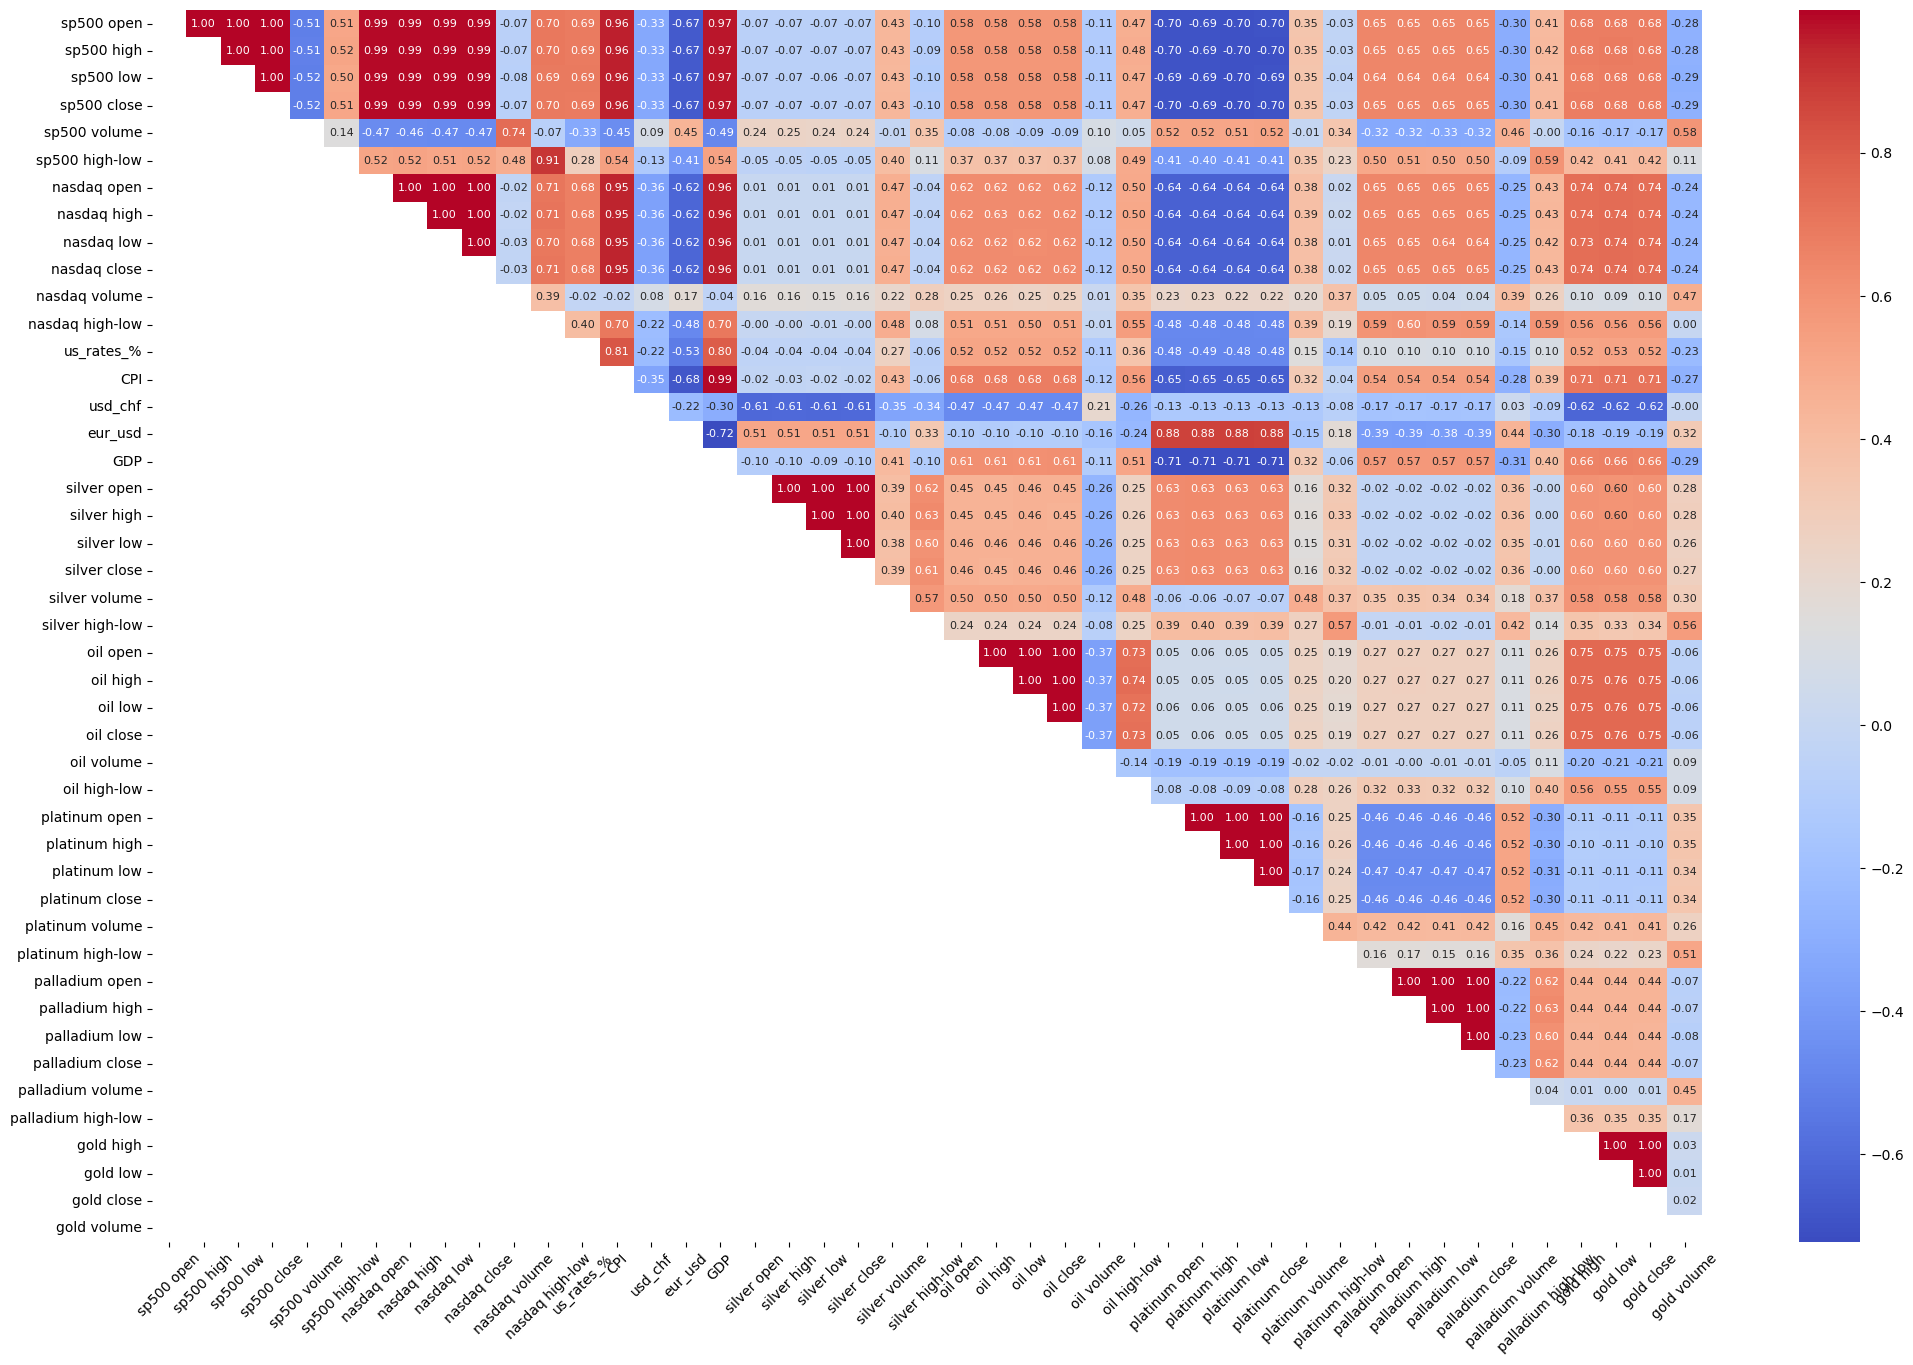

In [20]:
# Create mask for lower triangle
mask = np.tril(np.ones_like(corr_matric, dtype=bool))

plt.figure(figsize=(25,16))

sns.heatmap(
    corr_matric,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8},
    cmap="coolwarm"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [21]:
# correlation matrix
corr_matrix = X.corr(numeric_only=True).abs()

# upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# columns having correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Columns to drop:")
print(to_drop)

# drop columns
X_Modified = X.drop(columns=to_drop)
X_Modified

Columns to drop:
['sp500 high', 'sp500 low', 'sp500 close', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq high-low', 'CPI', 'GDP', 'silver high', 'silver low', 'silver close', 'oil high', 'oil low', 'oil close', 'platinum high', 'platinum low', 'platinum close', 'palladium high', 'palladium low', 'palladium close', 'gold low', 'gold close']


,date,sp500 open,sp500 volume,sp500 high-low,nasdaq volume,us_rates_%,usd_chf,eur_usd,silver open,silver volume,...,oil volume,oil high-low,platinum open,platinum volume,platinum high-low,palladium open,palladium volume,palladium high-low,gold high,gold volume
0,2010-01-14,114.49,115646960.0,0.720,75209000.0,0.13,1.0206,1.4478,18.58,69804.0,...,8575821.0,0.5600,160.13,228500.0,2.1300,43.93,364528.0,1.1600,112.37,18305238.0
1,2010-01-15,114.73,212252769.0,1.640,126849300.0,0.13,1.0264,1.4376,18.54,205106.0,...,12615299.0,0.7400,160.68,189900.0,1.7500,45.18,442210.0,1.3600,112.01,18000724.0
3,2010-01-19,113.62,138671890.0,1.540,84388200.0,0.13,1.0340,1.4269,18.53,130552.0,...,8180157.0,0.9199,162.23,295900.0,3.0278,46.01,629150.0,1.3800,111.75,10467927.0
4,2010-01-20,114.28,216330645.0,1.470,145680000.0,0.13,1.0453,1.4094,18.31,230907.0,...,11438685.0,0.4700,163.51,438200.0,4.4200,46.59,643198.0,2.1400,110.05,17534231.0
5,2010-01-21,113.92,344747028.0,2.710,204939600.0,0.13,1.0426,1.4106,17.82,198067.0,...,13716561.0,1.3200,161.86,247600.0,3.3800,46.60,388457.0,1.9100,108.78,25747831.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,2024-10-11,576.05,42267994.0,4.420,20644497.0,5.13,0.8574,1.0942,29.98,553812.0,...,3642400.0,1.1900,89.65,127968.0,1.2099,98.40,320800.0,1.6999,245.92,5789546.0
3897,2024-10-15,584.59,54203636.0,6.355,34784506.0,5.13,0.8621,1.0899,29.89,570678.0,...,4116689.0,1.2800,90.27,145789.0,1.1500,92.90,143277.0,1.8740,246.55,5640831.0
3898,2024-10-16,579.78,30725436.0,3.870,22996776.0,5.13,0.8642,1.0873,30.53,740840.0,...,2195339.0,1.1405,91.25,127453.0,1.0146,93.58,62828.0,1.4200,248.09,5431939.0
3899,2024-10-17,585.91,34393714.0,3.960,27210658.0,5.13,0.8654,1.0837,30.31,675311.0,...,2541657.0,1.5300,91.96,193978.0,1.8399,94.64,52414.0,1.4859,249.06,5176170.0


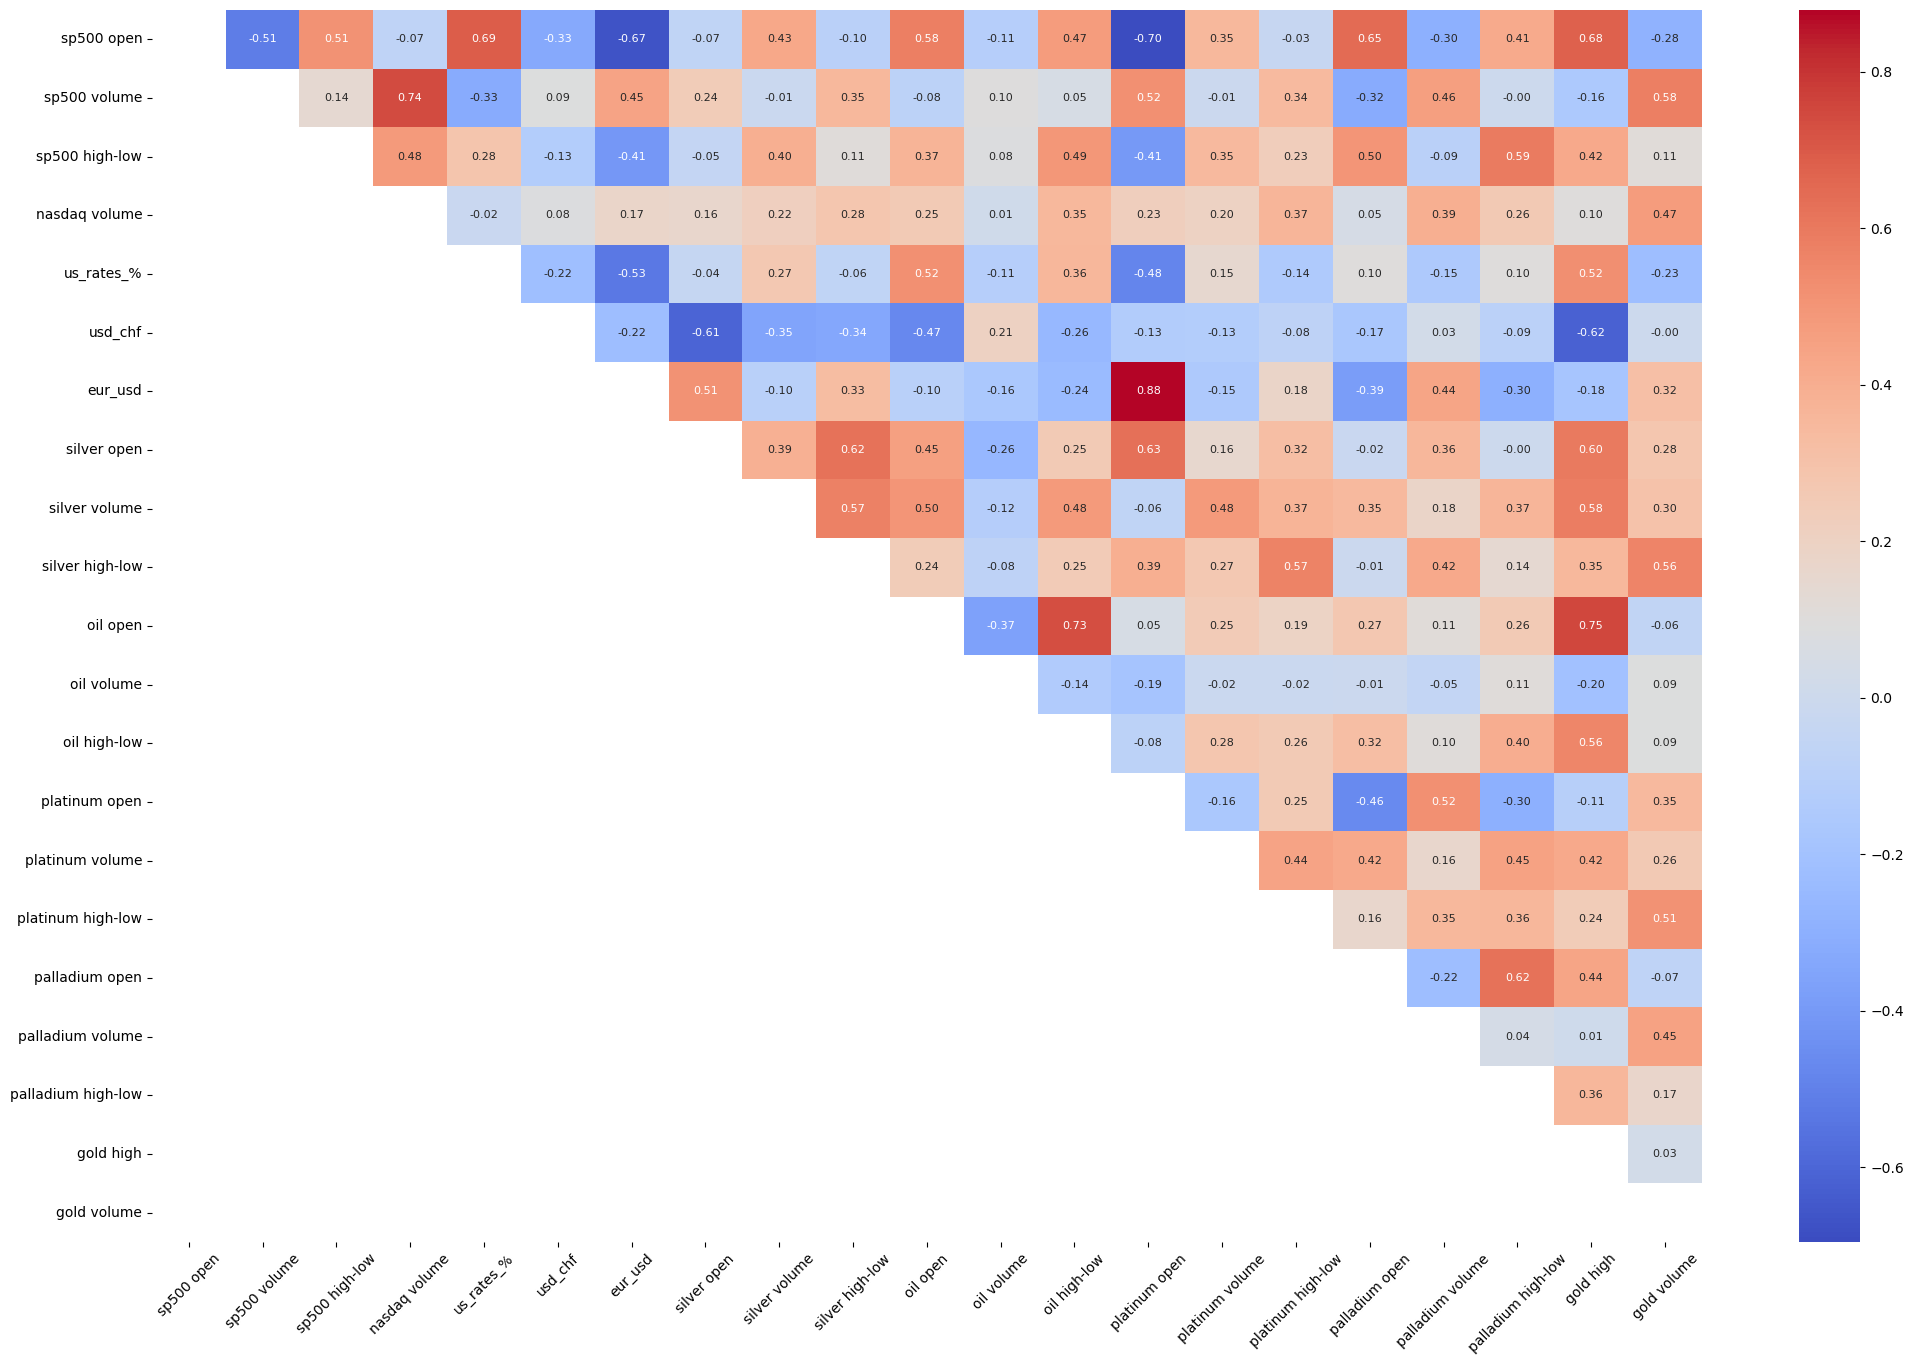

In [22]:
corr_matrix = X_Modified.corr(numeric_only=True)
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(25,16))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8},
    cmap="coolwarm"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [23]:
y

,gold open
0,111.51
1,111.35
3,110.95
4,109.97
5,108.48
...,...
3895,244.50
3897,244.99
3898,247.62
3899,247.75


### Now whole Data is Precessed and Cleaned, also no multicoliniarity is there also 

In [24]:
# Import Liberies for ML model ttraining 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
# Our Data is : X_Modified and y 

In [25]:
# Train Test Splite : 
X_train, X_test, y_train, y_test = train_test_split(X_Modified,y,test_size=0.2,random_state=42)

In [26]:
X_train_Data = X_train.iloc[:,0:1]
X_train = X_train.iloc[:,1:]
X_test_Data = X_test.iloc[:,0:1]
X_test = X_test.iloc[:,1:]

In [27]:
# Convert the data data into Standard data all features are into same scale :
Scaler = StandardScaler()
X_train_Scaled = Scaler.fit_transform(X_train)
X_test_Scaled = Scaler.transform(X_test)

In [28]:
# Convert scaled array back to DataFrame
X_train_Scaled = pd.DataFrame(
    X_train_Scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_Scaled = pd.DataFrame(
    X_test_Scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Merge Date column with scaled data
X_train_final = pd.concat([X_train_Data, X_train_Scaled], axis=1)
X_test_final = pd.concat([X_test_Data, X_test_Scaled], axis=1)

In [29]:
X_train_final.head()

,date,sp500 open,sp500 volume,sp500 high-low,nasdaq volume,us_rates_%,usd_chf,eur_usd,silver open,silver volume,...,oil volume,oil high-low,platinum open,platinum volume,platinum high-low,palladium open,palladium volume,palladium high-low,gold high,gold volume
2642,2020-01-14,0.483366,-0.714336,-0.469080,-0.784056,0.215180,0.388674,-0.682325,-0.653178,-0.595278,...,0.070138,-0.929366,-0.608149,0.240950,-0.449688,1.596322,-0.475676,0.673099,-0.002057,-0.496780
3062,2021-08-16,1.458351,-0.552326,0.451471,-0.386164,-0.655192,-0.679866,-0.104666,0.258300,-0.377540,...,-0.369575,0.911666,-0.489714,-0.304615,-0.645675,2.363029,-0.533537,1.475891,0.737386,-0.297890
3392,2022-11-16,1.060645,-0.631137,-0.016289,0.138835,1.544584,-0.058801,-1.339569,-0.083910,-0.072692,...,-0.412949,0.528973,-0.536582,0.131170,0.142413,1.456182,-0.633082,0.845768,0.679821,-0.987922
3075,2021-09-02,1.531563,-1.004344,-0.334365,-0.748708,-0.661154,-0.610430,-0.031341,0.298847,0.028606,...,-0.324968,-0.227661,-0.544182,0.752930,0.118076,2.006373,-0.541579,0.144311,0.814141,-0.828545
1116,2014-04-04,-0.664445,0.834973,0.211978,3.268283,-0.655192,-1.075265,1.619369,-0.226632,-0.559035,...,-0.442311,-0.763372,0.955573,-0.843489,-0.825091,-0.565562,-0.351594,-0.614967,-0.682223,-0.381778


In [30]:
X_test_final.head()

,date,sp500 open,sp500 volume,sp500 high-low,nasdaq volume,us_rates_%,usd_chf,eur_usd,silver open,silver volume,...,oil volume,oil high-low,platinum open,platinum volume,platinum high-low,palladium open,palladium volume,palladium high-low,gold high,gold volume
2255,2018-07-27,0.118891,-0.510870,0.152105,0.541497,0.429792,0.895942,-0.208394,-1.016472,-0.672291,...,-0.044207,-0.645666,-1.016972,-0.703744,-1.200494,-0.365979,-0.521364,-0.434293,-1.015284,-0.721607
1848,2017-01-11,-0.358773,-0.541874,-0.570116,-0.931776,-0.321351,1.403209,-1.244783,-0.820229,-0.639754,...,0.491516,-0.479822,-0.556215,-0.144023,0.844157,-0.647641,-0.341831,-0.584175,-1.085524,0.058625
3884,2024-09-26,2.539864,-0.924330,0.664770,-0.501073,2.349380,-1.952857,-0.634038,1.520098,0.777311,...,-0.374062,1.180276,-0.588832,1.404012,-0.423799,-0.220483,-0.012616,-0.327291,3.477921,-0.421472
3020,2021-06-18,1.229805,0.098019,0.035389,0.387929,-0.661154,-0.502419,-0.018822,0.605376,0.275913,...,-0.321957,0.124097,-0.362729,1.895777,1.640918,2.214768,-0.234628,2.700509,0.714429,1.030558
1790,2016-10-24,-0.453390,-0.752671,-0.820836,-0.990411,-0.470387,0.857366,-0.898724,-0.622363,-0.444634,...,1.086140,-0.748281,-0.631266,-0.657622,-0.008266,-0.850506,-0.601904,-0.426406,-0.841899,-0.681729


In [31]:
# Convert to datetime
X_train_final['date'] = pd.to_datetime(X_train_final['date'])
X_test_final['date'] = pd.to_datetime(X_test_final['date'])

# Extract useful features
X_train_final['year'] = X_train_final['date'].dt.year
X_train_final['month'] = X_train_final['date'].dt.strftime('%m')
X_train_final['day'] = X_train_final['date'].dt.strftime('%d')
X_train_final['weekday'] = X_train_final['date'].dt.weekday

X_test_final['year'] = X_test_final['date'].dt.year
X_test_final['month'] = X_test_final['date'].dt.strftime('%m')
X_test_final['day'] = X_test_final['date'].dt.strftime('%d')
X_test_final['weekday'] = X_test_final['date'].dt.weekday

# Remove original string date column
X_train_final = X_train_final.drop(columns=['date'])
X_test_final = X_test_final.drop(columns=['date'])

In [32]:
X_train_final.head()
X_columns = X_train_final.columns

In [33]:
X_test_final.head()

,sp500 open,sp500 volume,sp500 high-low,nasdaq volume,us_rates_%,usd_chf,eur_usd,silver open,silver volume,silver high-low,...,platinum high-low,palladium open,palladium volume,palladium high-low,gold high,gold volume,year,month,day,weekday
2255,0.118891,-0.510870,0.152105,0.541497,0.429792,0.895942,-0.208394,-1.016472,-0.672291,-0.859376,...,-1.200494,-0.365979,-0.521364,-0.434293,-1.015284,-0.721607,2018,07,27,4
1848,-0.358773,-0.541874,-0.570116,-0.931776,-0.321351,1.403209,-1.244783,-0.820229,-0.639754,-0.232159,...,0.844157,-0.647641,-0.341831,-0.584175,-1.085524,0.058625,2017,01,11,2
3884,2.539864,-0.924330,0.664770,-0.501073,2.349380,-1.952857,-0.634038,1.520098,0.777311,0.454792,...,-0.423799,-0.220483,-0.012616,-0.327291,3.477921,-0.421472,2024,09,26,3
3020,1.229805,0.098019,0.035389,0.387929,-0.661154,-0.502419,-0.018822,0.605376,0.275913,-0.142557,...,1.640918,2.214768,-0.234628,2.700509,0.714429,1.030558,2021,06,18,4
1790,-0.453390,-0.752671,-0.820836,-0.990411,-0.470387,0.857366,-0.898724,-0.622363,-0.444634,-0.115676,...,-0.008266,-0.850506,-0.601904,-0.426406,-0.841899,-0.681729,2016,10,24,0


In [34]:
y_train.head()

,gold open
2642,145.4005
3062,166.7300
3392,165.4100
3075,169.5000
1116,125.2000


In [35]:
y_test.head()

,gold open
2255,115.92
1848,112.87
3884,246.44
3020,166.14
1790,121.28


In [36]:
X_train_final = X_train_final.to_numpy()

In [37]:
len(X_train_final)

2941

In [38]:
X_test_final = X_test_final.to_numpy()

In [39]:
len(X_test_final)

736

In [40]:
y_train = y_train['gold open'].values

In [41]:
len(y_train)

2941

In [42]:
y_test = y_test['gold open'].values

In [43]:
len(y_test)

736

In [44]:
# Model Tranning :
Linear_Model = LinearRegression()
Linear_Model.fit(X_train_final,y_train)

LinearRegression()

In [45]:
Predicted_value = Linear_Model.predict(X_test_final)

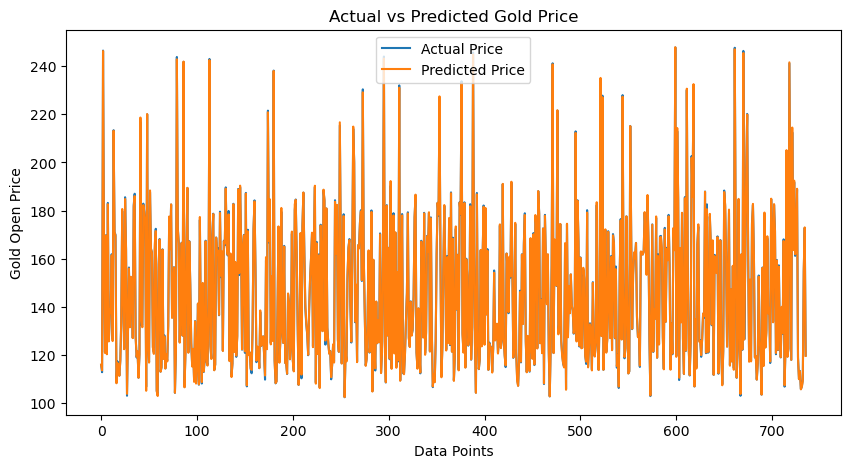

In [46]:
# Plot
plt.figure(figsize=(10,5))

plt.plot(y_test, label='Actual Price')
plt.plot(Predicted_value, label='Predicted Price')

plt.xlabel("Data Points")
plt.ylabel("Gold Open Price")
plt.title("Actual vs Predicted Gold Price")

plt.legend()
plt.show()

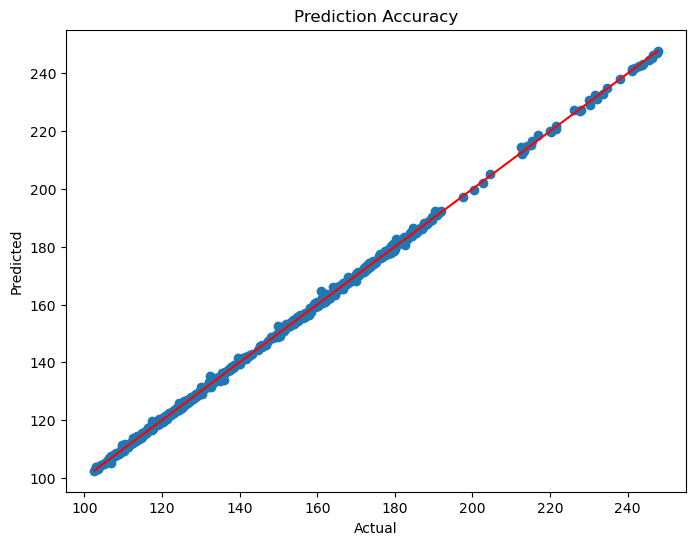

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, Predicted_value)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction Accuracy")

plt.show()

In [48]:
Predicted_value

array([116.00509635, 113.65243775, 246.26677676, 166.06079064,
       120.86704151, 169.60445844, 120.31960774, 182.66740257,
       125.65821111, 136.5560704 , 139.51453398, 161.44157502,
       125.80214794, 213.15403329, 171.07391917, 169.43815118,
       108.28442547, 116.68079188, 115.93673562, 111.4059201 ,
       117.52256958, 134.73406449, 180.65540822, 148.27927432,
       122.41818394, 184.80912573, 163.33533869, 103.88105249,
       129.98211062, 155.96022451, 131.51869822, 152.51697529,
       150.45193404, 127.01729527, 181.53002496, 186.02497927,
       127.63593207, 119.33285998, 121.54380126, 110.56628106,
       120.23327275, 218.64355988, 135.35364852, 131.5522359 ,
       182.27574217, 179.23115554, 174.89682052, 105.15340827,
       220.08837172, 123.97604261, 116.85409578, 188.36280186,
       164.23887036, 162.45234704, 123.08979182, 120.46679684,
       166.1549444 , 171.51119722, 104.99836503, 102.98584349,
       156.32381611, 167.946564  , 113.09231252, 114.87

In [49]:
y_test

array([115.92  , 112.87  , 246.44  , 166.14  , 121.28  , 169.75  ,
       120.46  , 183.17  , 125.78  , 136.27  , 139.77  , 161.86  ,
       126.54  , 213.38  , 171.06  , 169.94  , 108.54  , 117.39  ,
       116.01  , 111.46  , 117.78  , 133.68  , 179.76  , 148.66  ,
       122.7   , 185.54  , 163.97  , 103.09  , 129.71  , 156.35  ,
       131.77  , 149.9   , 150.26  , 127.11  , 182.245 , 186.99  ,
       127.57  , 119.    , 121.45  , 110.57  , 120.38  , 216.85  ,
       132.42  , 132.6   , 182.87  , 179.6   , 175.11  , 106.79  ,
       219.96  , 124.    , 117.16  , 187.61  , 164.02  , 162.58  ,
       123.3   , 121.16  , 164.03  , 172.4299, 105.18  , 103.38  ,
       157.82  , 168.21  , 113.08  , 114.89  , 163.89  , 118.48  ,
       128.15  , 114.45  , 119.23  , 117.76  , 132.33  , 177.39  ,
       164.22  , 182.5   , 135.71  , 145.73  , 156.49  , 104.29  ,
       120.96  , 243.79  , 172.7   , 166.54  , 125.37  , 149.86  ,
       166.65  , 128.05  , 241.77  , 106.78  , 121.47  , 163.2

In [50]:
R2_Schore = r2_score(y_test,Predicted_value)

In [51]:
R2_Schore

0.9996372790614504

In [52]:
MAE = mean_absolute_error(y_test,Predicted_value)

In [53]:
MAE

0.42458495053940587

In [54]:
RMSE = root_mean_squared_error(y_test, Predicted_value)

In [55]:
RMSE

0.5909368873029792

# Decision Tree Model :

In [56]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [57]:
Tree_Model = DecisionTreeRegressor(random_state=42)

In [58]:
Tree_Model.fit(X_train_final,y_train)

DecisionTreeRegressor(random_state=42)

In [59]:
Predicted_value_tree = Tree_Model.predict(X_test_final)

In [60]:
Predicted_value_tree

array([116.    , 113.88  , 245.2   , 165.39  , 121.21  , 167.38  ,
       120.24  , 182.91  , 125.61  , 137.22  , 138.07  , 160.74  ,
       126.2   , 210.57  , 169.32  , 169.8   , 107.63  , 116.22  ,
       116.1   , 111.73  , 117.45  , 134.94  , 181.69  , 148.74  ,
       122.66  , 183.76  , 163.15  , 104.15  , 129.82  , 155.18  ,
       131.43  , 151.46  , 150.15  , 127.18  , 183.57  , 184.69  ,
       126.53  , 119.75  , 121.41  , 109.23  , 120.46  , 220.14  ,
       133.83  , 132.24  , 182.91  , 179.44  , 175.83  , 106.61  ,
       219.02  , 124.08  , 116.59  , 188.69  , 165.2   , 162.21  ,
       122.75  , 121.2   , 166.93  , 172.64  , 105.03  , 103.75  ,
       158.12  , 168.42  , 113.24  , 114.66  , 164.2   , 118.16  ,
       128.14  , 114.8   , 120.67  , 117.45  , 132.    , 177.19  ,
       164.06  , 183.03  , 135.47  , 145.12  , 156.37  , 104.15  ,
       121.54  , 250.    , 172.71  , 166.14  , 125.09  , 149.48  ,
       165.75  , 126.47  , 250.    , 107.18  , 121.27  , 161.9

In [61]:
R2_Schore_tree = r2_score(y_test,Predicted_value_tree) 

In [62]:
R2_Schore_tree

0.9989678214295798

In [63]:
MAE_tree = mean_absolute_error(y_test,Predicted_value_tree)

In [64]:
MAE_tree

0.6450349184782608

In [65]:
RMSE_tree = root_mean_squared_error(y_test,Predicted_value_tree)

In [66]:
RMSE

0.5909368873029792

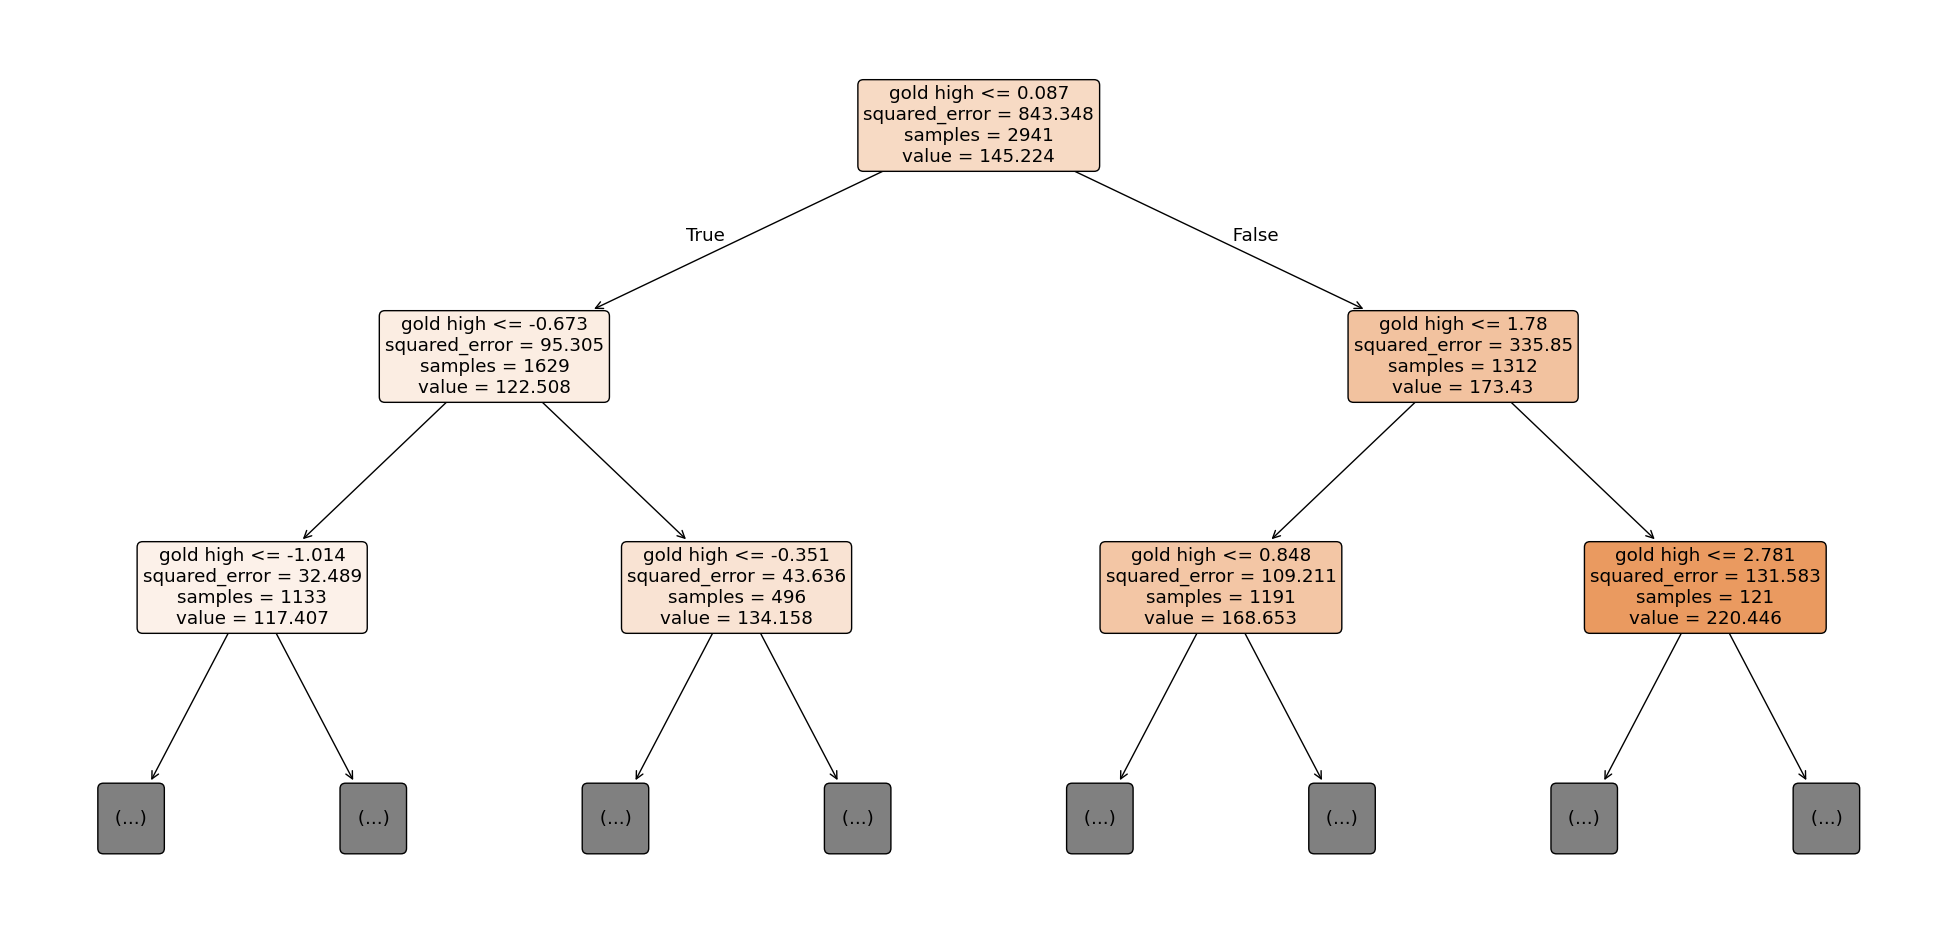

In [67]:
plt.figure(figsize=(25,12))

plot_tree(
    Tree_Model,
    max_depth=2,
    filled=True,
    feature_names=X_columns,
    rounded=True
)

plt.show()

# Random Forest Model :

In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
X_train_final

array([[0.4833657125796675, -0.7143355646592826, -0.46908033967008994,
        ..., '01', '14', 1],
       [1.4583513979516618, -0.5523261208090422, 0.4514713153429068, ...,
        '08', '16', 0],
       [1.0606445256083101, -0.6311371844835216, -0.016288671960470374,
        ..., '11', '16', 2],
       ...,
       [-0.9125645869961597, 0.3311055542450798, -0.6674105742867239,
        ..., '06', '26', 2],
       [1.9144441378369383, -0.7303411255805203, 0.13900764382425143,
        ..., '02', '15', 3],
       [0.6643952177185729, 0.5133836215821628, 6.124464441357995, ...,
        '10', '13', 3]], dtype=object)

In [70]:
y_train

array([145.4005, 166.73  , 165.41  , ..., 119.88  , 185.6   , 153.48  ])

In [73]:
Random_Model = RandomForestRegressor(random_state=42,max_depth=5)

In [74]:
Random_Model.fit(X_train_final,y_train)

RandomForestRegressor(max_depth=5, random_state=42)

In [75]:
Predicted_value_Random = Random_Model.predict(X_test_final)

In [76]:
Predicted_value_Random

array([115.74332999, 113.11653938, 244.71387311, 167.21438272,
       121.0745992 , 167.89111135, 120.43963516, 181.88827386,
       125.38874399, 136.46629917, 139.19147655, 162.3653487 ,
       126.19776909, 214.97539855, 171.48726988, 167.93516874,
       107.8522522 , 116.58645912, 115.88878014, 112.11001708,
       118.19145648, 135.32046123, 181.88827386, 150.23664513,
       122.41522392, 185.25309661, 162.41606152, 103.56585984,
       129.8131518 , 156.35847819, 130.70714529, 151.90260771,
       151.90260771, 126.49701964, 182.01143686, 187.50964895,
       127.41524906, 119.20443176, 121.16755557, 110.10165111,
       120.43963516, 219.24083013, 135.60359411, 132.42674773,
       181.88827386, 179.60534652, 175.5783171 , 107.8522522 ,
       219.88315171, 123.85816473, 116.15634484, 187.68464599,
       162.62180046, 162.3653487 , 123.12732604, 121.03017307,
       167.53451387, 172.13734257, 104.81553519, 103.56585984,
       157.43689056, 167.57205075, 112.96231849, 115.52

In [77]:
R2_Schore_Random = r2_score(y_test,Predicted_value_Random)

In [78]:
R2_Schore_Random

0.9989267493297533

In [79]:
MAE_Random = mean_absolute_error(y_test,Predicted_value_Random)

In [81]:
MAE_Random

0.7292924748931938

In [82]:
RMSE_Random = root_mean_squared_error(y_test,Predicted_value)

In [83]:
RMSE_Random

0.5909368873029792